In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# (optional) make plots appear inline and set a style
%matplotlib inline
sns.set_context("notebook")

# 3) Convenience: point to your HDFS folder
hdfs_dir = os.path.abspath(os.path.join("..", "data", "HDFS", "preprocessed"))

print("Files in", hdfs_dir)
for fn in sorted(os.listdir(hdfs_dir)):
    print(" ", fn)

Files in c:\Users\smirn\VSCodeProjects\LogAD\data\HDFS\preprocessed
  Event_occurrence_matrix.csv
  Event_traces.csv
  HDFS.log_templates.csv
  HDFS.npz
  anomaly_label.csv


In [3]:
templates_df     = pd.read_csv(os.path.join(hdfs_dir, "HDFS.log_templates.csv"))
labels_df        = pd.read_csv(os.path.join(hdfs_dir, "anomaly_label.csv"))
traces_df        = pd.read_csv(os.path.join(hdfs_dir, "Event_traces.csv"))
occurrence_df    = pd.read_csv(os.path.join(hdfs_dir, "Event_occurrence_matrix.csv"))

print("Templates:",     templates_df.shape)
print("Anomaly labels:",labels_df.shape)
print("Traces:",        traces_df.shape)
print("Occurrence:",    occurrence_df.shape)

Templates: (29, 2)
Anomaly labels: (575061, 2)
Traces: (575061, 6)
Occurrence: (575061, 32)


In [4]:
templates_df.head(), labels_df.head(), traces_df.head(), occurrence_df.iloc[:5, :5]

(  EventId                           EventTemplate
 0      E1  [*]Adding an already existing block[*]
 1      E2        [*]Verification succeeded for[*]
 2      E3                 [*]Served block[*]to[*]
 3      E4  [*]Got exception while serving[*]to[*]
 4      E5    [*]Receiving block[*]src:[*]dest:[*],
                     BlockId    Label
 0  blk_-1608999687919862906   Normal
 1   blk_7503483334202473044   Normal
 2  blk_-3544583377289625738  Anomaly
 3  blk_-9073992586687739851   Normal
 4   blk_7854771516489510256   Normal,
                     BlockId    Label  Type  \
 0  blk_-1608999687919862906  Success   NaN   
 1   blk_7503483334202473044  Success   NaN   
 2  blk_-3544583377289625738     Fail  21.0   
 3  blk_-9073992586687739851  Success   NaN   
 4   blk_7854771516489510256  Success   NaN   
 
                                             Features  \
 0  [E5,E22,E5,E5,E11,E11,E9,E9,E11,E9,E26,E26,E26...   
 1  [E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...   
 2  [E5,E

In [5]:
print("Distinct templates:", templates_df['EventId'].nunique())
templates_df['EventId'].value_counts().head(10)

Distinct templates: 29


E1     1
E16    1
E28    1
E27    1
E26    1
E25    1
E24    1
E23    1
E22    1
E21    1
Name: EventId, dtype: int64

Overall anomaly rate: 2.93% (16838/575061)


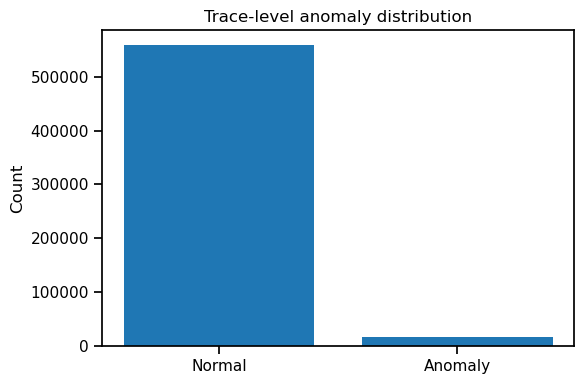

In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# path to your labels CSV
label_path = os.path.join(hdfs_dir, "anomaly_label.csv")

# init counters
normal = anomaly = 0

# stream in chunks of 1 million rows
for chunk in pd.read_csv(
    label_path,
    usecols=["Label"],
    dtype=str,       # read as strings
    chunksize=1_000_000
):
    vc = chunk["Label"].value_counts()
    normal  += int(vc.get("Normal",  0))
    anomaly += int(vc.get("Anomaly", 0))

total = normal + anomaly

# print the rate and raw counts
print(f"Overall anomaly rate: {anomaly/total:.2%} ({anomaly}/{total})")

# fast bar-plot
plt.figure(figsize=(6,4))
plt.bar(["Normal","Anomaly"], [normal, anomaly])
plt.title("Trace-level anomaly distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [11]:
# 3.5 Occurrence matrix summary
occurrence_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Type,16838.0,9.375638,11.344260,0.0,3.0,5.0,8.0,31.0
E1,575061.0,0.000017,0.005897,0.0,0.0,0.0,0.0,2.0
E2,575061.0,0.208736,0.580644,0.0,0.0,0.0,0.0,4.0
E3,575061.0,0.745531,2.517178,0.0,0.0,0.0,0.0,203.0
E4,575061.0,0.619425,1.604554,0.0,0.0,0.0,0.0,41.0
E5,575061.0,2.996607,0.220913,1.0,3.0,3.0,3.0,13.0
E6,575061.0,0.012341,0.146923,0.0,0.0,0.0,0.0,10.0
E7,575061.0,0.005940,0.080642,0.0,0.0,0.0,0.0,5.0
E8,575061.0,0.000085,0.009779,0.0,0.0,0.0,0.0,2.0
E9,575061.0,2.967536,0.310178,0.0,3.0,3.0,3.0,3.0


C:\Users\smirn\AppData\Local\Temp\ipykernel_5596\2697227856.py:4: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(sub.corr(), cmap='viridis')


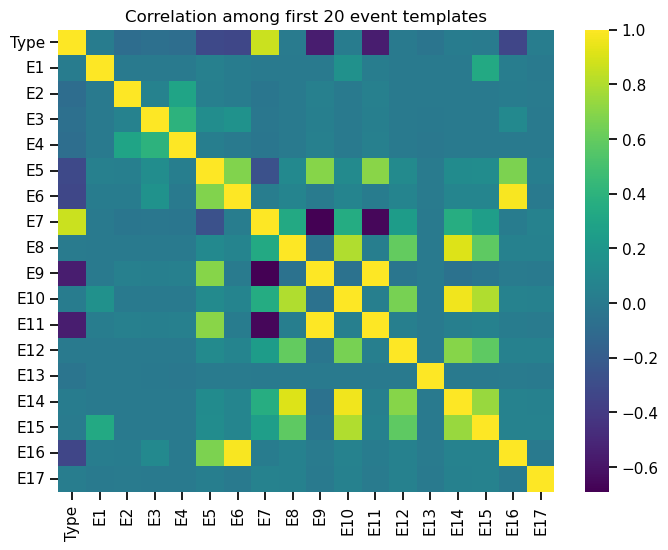

In [12]:
# 3.6 Heatmap of event co‐occurrence (first 20 templates for speed)
sub = occurrence_df.iloc[:, :20]
plt.figure(figsize=(8,6))
sns.heatmap(sub.corr(), cmap='viridis')
plt.title("Correlation among first 20 event templates")
plt.show()